In [1]:
!pip install wandb huggingface_hub -q

## weights and biases login

In [2]:
import wandb
wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

  2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

  ········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: happykumar_25afi21 (happykumar_25afi21-delhi-technological-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

## hugging face login

In [3]:
from huggingface_hub import notebook_login
notebook_login()

## importing libraries and setting parameters

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import matplotlib.pyplot as plt
import numpy as np
import os
from torch.utils.data import DataLoader, random_split
from huggingface_hub import HfApi, create_repo

# change to your huggingface username
HF_REPO = "HappyKumar25afi21/exp10-vit-resnet"

WANDB_PROJECT = "exp10-vit-resnet"
EPOCHS        = 4
BATCH_SIZE    = 128
NUM_CLASSES   = 10
PATCH_SIZE    = 4
IMG_SIZE      = 32
EMBED_DIM     = 128
NUM_HEADS     = 4
NUM_LAYERS    = 4
DEVICE        = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LOSS_FNS   = ["ce", "label_smooth", "focal"]
OPTIMIZERS = ["adam", "sgd", "rmsprop"]
MODELS     = ["vit", "resnet18"]
AUG_MODES  = ["no_aug", "aug"]

class_names = ['plane','car','bird','cat','deer','dog','frog','horse','ship','truck']
print(DEVICE)

cuda


## Dataset - Original and Augmented

100%|██████████| 170M/170M [00:03<00:00, 48.5MB/s] 


train=40000  val=10000  test=10000


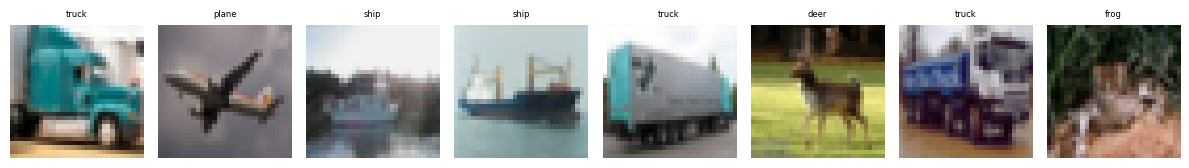

In [5]:
mean = (0.4914, 0.4822, 0.4465)
std  = (0.2023, 0.1994, 0.2010)

# without augmentation
transform_base = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

# with horizontal + vertical flip
transform_aug = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean, std)
])

full_base = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_base)
full_aug  = torchvision.datasets.CIFAR10(root='./data', train=True,  download=True, transform=transform_aug)
test_data = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

n_total = len(full_base)        # 50000
n_train = int(0.8 * n_total)   # 40000
n_val   = n_total - n_train    # 10000

gen = torch.Generator().manual_seed(42)
train_base, val_base = random_split(full_base, [n_train, n_val], generator=gen)
train_aug,  val_aug  = random_split(full_aug,  [n_train, n_val], generator=torch.Generator().manual_seed(42))

def make_loaders(train_set, val_set):
    tr = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2)
    vl = DataLoader(val_set,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    te = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    return tr, vl, te

loaders = {
    'no_aug': make_loaders(train_base, val_base),
    'aug':    make_loaders(train_aug,  val_aug)
}

print(f'train={n_train}  val={n_val}  test={len(test_data)}')

imgs, labels = next(iter(loaders['no_aug'][0]))
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    img = imgs[i].permute(1,2,0).numpy()
    img = img * np.array(std) + np.array(mean)
    axes[i].imshow(np.clip(img, 0, 1))
    axes[i].set_title(class_names[labels[i]], fontsize=6)
    axes[i].axis('off')
plt.tight_layout()
plt.show()

## Patch Embedding

In [6]:
class PatchEmbedding(nn.Module):
    def __init__(self, img_size, patch_size, in_channels, embed_dim):
        super(PatchEmbedding, self).__init__()
        self.num_patches = (img_size // patch_size) ** 2
        # use conv to split image into patches and project
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)           # (B, embed_dim, H/p, W/p)
        x = x.flatten(2)           # (B, embed_dim, num_patches)
        x = x.transpose(1, 2)     # (B, num_patches, embed_dim)
        return x

## Vision Transformer

In [7]:
class ViT(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3,
                 embed_dim=128, num_heads=4, num_layers=4, num_classes=10):
        super(ViT, self).__init__()

        self.patch_embed  = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches       = (img_size // patch_size) ** 2

        # learnable CLS token
        self.cls_token    = nn.Parameter(torch.zeros(1, 1, embed_dim))
        # learnable positional encoding
        self.pos_embed    = nn.Parameter(torch.zeros(1, num_patches + 1, embed_dim))

        encoder_layer     = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer  = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm         = nn.LayerNorm(embed_dim)

        # classification head
        self.head = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_classes)
        )

        nn.init.trunc_normal_(self.cls_token, std=0.02)
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)

        cls = self.cls_token.expand(B, -1, -1)
        x   = torch.cat([cls, x], dim=1)
        x   = x + self.pos_embed

        x   = self.transformer(x)
        x   = self.norm(x)
        # take CLS token output for classification
        out = self.head(x[:, 0])
        return out

## ResNet-18 Baseline

In [8]:
def get_resnet18():
    model = models.resnet18(weights=None)
    # adjust first conv for 32x32 input
    model.conv1   = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    model.fc      = nn.Linear(512, NUM_CLASSES)
    return model

## Loss Functions - CE, Label Smoothing, Focal

In [9]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, logits, targets):
        ce   = nn.functional.cross_entropy(logits, targets, reduction='none')
        pt   = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

def get_criterion(loss_type):
    if loss_type == 'ce':
        return nn.CrossEntropyLoss()
    elif loss_type == 'label_smooth':
        return nn.CrossEntropyLoss(label_smoothing=0.1)
    elif loss_type == 'focal':
        return FocalLoss(gamma=2.0)

## Optimizer Factory

In [10]:
def get_optimizer(model, name):
    if name == 'adam':
        return optim.Adam(model.parameters(), lr=1e-3)
    elif name == 'sgd':
        return optim.SGD(model.parameters(), lr=1e-2, momentum=0.9, weight_decay=5e-4)
    else:
        return optim.RMSprop(model.parameters(), lr=1e-3)

## Train and Eval Loops

In [11]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    correct    = 0
    total      = 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        out  = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == y).sum().item()
        total      += y.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct    = 0
    total      = 0
    with torch.no_grad():
        for x, y in loader:
            x, y  = x.to(DEVICE), y.to(DEVICE)
            out   = model(x)
            loss  = criterion(out, y)
            total_loss += loss.item()
            correct    += (out.argmax(1) == y).sum().item()
            total      += y.size(0)
    return total_loss / len(loader), correct / total

## Main Experiment Runner

In [12]:
results       = {}
saved_models  = {}

def run_experiment(arch, loss_type, opt_name, aug_mode):
    name = f'{arch}_{loss_type}_{opt_name}_{aug_mode}'
    print(f'\nstarting: {name}')

    wandb.init(project=WANDB_PROJECT, name=name, config={
        'arch': arch, 'loss': loss_type,
        'optimizer': opt_name, 'augmentation': aug_mode, 'epochs': EPOCHS
    })

    train_loader, val_loader, test_loader = loaders[aug_mode]

    if arch == 'vit':
        model = ViT(
            img_size=IMG_SIZE, patch_size=PATCH_SIZE, in_channels=3,
            embed_dim=EMBED_DIM, num_heads=NUM_HEADS,
            num_layers=NUM_LAYERS, num_classes=NUM_CLASSES
        ).to(DEVICE)
    else:
        model = get_resnet18().to(DEVICE)

    criterion = get_criterion(loss_type)
    optimizer = get_optimizer(model, opt_name)

    best_val_acc = 0

    for epoch in range(1, EPOCHS + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion)
        vl_loss, vl_acc = evaluate(model, val_loader, criterion)

        if vl_acc > best_val_acc:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pt')

        wandb.log({
            'epoch': epoch,
            'train_loss': tr_loss, 'train_acc': tr_acc,
            'val_loss':   vl_loss, 'val_acc':   vl_acc
        })
        print(f'  epoch {epoch}/{EPOCHS}  train_loss={tr_loss:.4f}  train_acc={tr_acc:.4f}  val_loss={vl_loss:.4f}  val_acc={vl_acc:.4f}')

    # load best checkpoint and test
    model.load_state_dict(torch.load(f'{name}_best.pt'))
    te_loss, te_acc = evaluate(model, test_loader, criterion)
    print(f'  test_loss={te_loss:.4f}  test_acc={te_acc:.4f}')
    wandb.log({'test_loss': te_loss, 'test_acc': te_acc})

    results[name]      = {'test_acc': te_acc, 'test_loss': te_loss}
    saved_models[name] = model

    wandb.finish()
    return model

## Quick Test

In [13]:
run_experiment('vit',      'ce', 'adam', 'no_aug')
run_experiment('resnet18', 'ce', 'adam', 'no_aug')


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7895  train_acc=0.3306  val_loss=1.5360  val_acc=0.4373
  epoch 2/4  train_loss=1.4201  train_acc=0.4749  val_loss=1.2475  val_acc=0.5409
  epoch 3/4  train_loss=1.2195  train_acc=0.5565  val_loss=1.1682  val_acc=0.5841
  epoch 4/4  train_loss=1.1125  train_acc=0.5977  val_loss=1.0799  val_acc=0.6112
  test_loss=1.0879  test_acc=0.6099


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅▇█
val_loss,█▄▂▁
epoch,4
test_acc,0.6099
test_loss,1.08788
train_acc,0.59772



starting: resnet18_ce_adam_no_aug


  epoch 1/4  train_loss=1.2674  train_acc=0.5370  val_loss=1.3970  val_acc=0.5654
  epoch 2/4  train_loss=0.7734  train_acc=0.7275  val_loss=0.8698  val_acc=0.7046
  epoch 3/4  train_loss=0.5734  train_acc=0.7998  val_loss=0.8203  val_acc=0.7308
  epoch 4/4  train_loss=0.4262  train_acc=0.8493  val_loss=0.7068  val_acc=0.7662
  test_loss=0.7551  test_acc=0.7568


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▆▇█
val_loss,█▃▂▁
epoch,4
test_acc,0.7568
test_loss,0.75513
train_acc,0.8493


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): Identity()
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), p

## Full Grid - all combinations

In [14]:
for arch in MODELS:
    for aug in AUG_MODES:
        for lf in LOSS_FNS:
            for opt in OPTIMIZERS:
                run_experiment(arch, lf, opt, aug)


starting: vit_ce_adam_no_aug


  epoch 1/4  train_loss=1.7874  train_acc=0.3235  val_loss=1.5520  val_acc=0.4239
  epoch 2/4  train_loss=1.4379  train_acc=0.4684  val_loss=1.3113  val_acc=0.5158
  epoch 3/4  train_loss=1.2278  train_acc=0.5525  val_loss=1.1435  val_acc=0.5821
  epoch 4/4  train_loss=1.1052  train_acc=0.5985  val_loss=1.0393  val_acc=0.6228
  test_loss=1.0465  test_acc=0.6177


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▄▇█
val_loss,█▅▂▁
epoch,4
test_acc,0.6177
test_loss,1.04654
train_acc,0.5985



starting: vit_ce_sgd_no_aug


  epoch 1/4  train_loss=1.9145  train_acc=0.2877  val_loss=1.7323  val_acc=0.3560
  epoch 2/4  train_loss=1.6733  train_acc=0.3759  val_loss=1.5784  val_acc=0.4209
  epoch 3/4  train_loss=1.5284  train_acc=0.4390  val_loss=1.4403  val_acc=0.4665
  epoch 4/4  train_loss=1.4292  train_acc=0.4803  val_loss=1.3640  val_acc=0.5008
  test_loss=1.3785  test_acc=0.4980


...

  epoch 1/4  train_loss=1.1598  train_acc=0.3810  val_loss=1.0596  val_acc=0.4429
  epoch 2/4  train_loss=0.8028  train_acc=0.5345  val_loss=0.8281  val_acc=0.5519
  epoch 3/4  train_loss=0.6512  train_acc=0.6110  val_loss=0.6418  val_acc=0.6223
  epoch 4/4  train_loss=0.5569  train_acc=0.6565  val_loss=0.6556  val_acc=0.6153
  test_loss=0.6664  test_acc=0.6139


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▅██
val_loss,█▄▁▁
epoch,4
test_acc,0.6139
test_loss,0.66639
train_acc,0.6565



starting: resnet18_focal_rmsprop_aug


  epoch 1/4  train_loss=1.2515  train_acc=0.3543  val_loss=1.2136  val_acc=0.3607
  epoch 2/4  train_loss=0.8355  train_acc=0.5172  val_loss=1.1509  val_acc=0.4456
  epoch 3/4  train_loss=0.6562  train_acc=0.6015  val_loss=0.8318  val_acc=0.5601
  epoch 4/4  train_loss=0.5429  train_acc=0.6595  val_loss=0.5377  val_acc=0.6615
  test_loss=0.5493  test_acc=0.6524


epoch,▁▃▆█
test_acc,▁
test_loss,▁
train_acc,▁▅▇█
train_loss,█▄▂▁
val_acc,▁▃▆█
val_loss,█▇▄▁
epoch,4
test_acc,0.6524
test_loss,0.54931
train_acc,0.65948


## Results Summary

In [15]:
print(f'{"config":<50} {"test_acc":>10} {"test_loss":>10}')
print('-' * 72)
for k, v in sorted(results.items(), key=lambda x: -x[1]['test_acc']):
    print(f'{k:<50} {v["test_acc"]:>10.4f} {v["test_loss"]:>10.4f}')

best = max(results, key=lambda x: results[x]['test_acc'])
print(f'\nbest: {best}  acc={results[best]["test_acc"]:.4f}')

config                                               test_acc  test_loss
------------------------------------------------------------------------
resnet18_label_smooth_adam_no_aug                      0.8114     0.9456
resnet18_ce_adam_no_aug                                0.7734     0.7109
resnet18_focal_adam_no_aug                             0.7586     0.4145
resnet18_ce_rmsprop_no_aug                             0.7462     0.7253
resnet18_label_smooth_rmsprop_no_aug                   0.7419     1.1000
resnet18_label_smooth_adam_aug                         0.7140     1.1461
resnet18_ce_adam_aug                                   0.6986     0.8681
resnet18_focal_adam_aug                                0.6866     0.4991
resnet18_label_smooth_sgd_no_aug                       0.6841     1.2305
resnet18_label_smooth_sgd_aug                          0.6775     1.2267
resnet18_focal_sgd_no_aug                              0.6736     0.5446
resnet18_ce_sgd_aug                                

## Upload to HuggingFace

In [16]:
create_repo(HF_REPO, exist_ok=True)
api = HfApi()

for name in saved_models.keys():
    fname = f'{name}_best.pt'
    if os.path.exists(fname):
        api.upload_file(
            path_or_fileobj=fname,
            path_in_repo=f'models/{fname}',
            repo_id=HF_REPO
        )
        print(f'uploaded: {fname}')

print(f'https://huggingface.co/{HF_REPO}')

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: vit_ce_adam_no_aug_best.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

uploaded: resnet18_focal_sgd_aug_best.pt


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

uploaded: resnet18_focal_rmsprop_aug_best.pt
https://huggingface.co/HappyKumar25afi21/exp10-vit-resnet


In [17]:
username = wandb.api.viewer()['entity']
print(f'W&B : https://wandb.ai/{username}/{WANDB_PROJECT}')
print(f'HF  : https://huggingface.co/{HF_REPO}')

W&B : https://wandb.ai/happykumar_25afi21-delhi-technological-university/exp10-vit-resnet
HF  : https://huggingface.co/HappyKumar25afi21/exp10-vit-resnet
